# Formulación QUBO para el reto Falcon Reservoir

**Documento de trabajo en Google Colab**  
**Tema:** Programación resiliente de liberaciones para el International Falcon Reservoir.  
**Enfoque:** formulación QUBO/BQM basada en variables binarias, método de penalización y evaluación con el Storage Resilience Score (SRS).

Este cuaderno deja documentado el planteamiento matemático y contiene código base para:

1. preparar datos semanales de almacenamiento y liberación observada;
2. calcular parámetros oficiales del benchmark;
3. evaluar la operación histórica y una regla clásica de conservación;
4. construir una QUBO/BQM con codificación binaria de niveles de ajuste;
5. resolver una instancia pequeña con recocido simulado;
6. comparar SRS, factibilidad y secuencia de liberaciones.

> **Nota de uso:** el cuaderno está preparado para ejecutarse con datos sintéticos de demostración. Para el reto real, reemplaza la sección de datos por el archivo semanal del Falcon Reservoir.


## 1. Fuentes usadas

La documentación se basa únicamente en los archivos adjuntos del proyecto:

- `FalconChallenge_V6.pdf`: define el reto, la métrica SRS, las restricciones, los niveles oficiales de ajuste, los pesos del benchmark, las instancias de escalamiento y los requisitos de implementación cuántica.
- `contents.ipynb`: identifica las referencias internas del tutorial de quantum annealing: **QUBO Mathematical Definition**, **Penalty Method**, **Higher Order Models & Quadratization**, **Binary Quadratic Model**, **Simulated Annealing**, **Quantum Annealing** y **D-Wave Hybrid Solvers**.
- `Taha - Investigación de operaciones (9a. ed.).pdf`, `Métodos cuantitativos para administración`, `Render - Métodos cuantitativos para los negocios`, `Winston - Operations Research` y `Linear Programming and Network Flows`: se usan como marco de modelación: variables de decisión, función objetivo, restricciones, factibilidad, optimalidad y variables binarias.

La lógica QUBO usada aquí sigue esta ruta:

\[
\text{problema combinatorio}
\rightarrow
\text{variables binarias}
\rightarrow
\text{QUBO}
\rightarrow
\text{BQM}
\rightarrow
\text{recocido simulado/quantum annealing/híbrido}.
\]


## 2. Resumen del reto Falcon

El problema busca una secuencia de ajustes de liberación:

\[
u(t), \qquad t=0,1,\dots,T-1.
\]

La liberación optimizada se define como:

\[
R(t)=R^{obs}(t)+u(t).
\]

La dinámica simplificada de almacenamiento es:

\[
S^{opt}(t+1)=S^{opt}(t)+\Delta S^{obs}(t)-u(t).
\]

La métrica oficial es:

\[
SRS=-\left(w_1C_{crit}+w_2C_{dev}+w_3C_{smooth}\right),
\]

con:

\[
C_{crit}=\sum_{t=0}^{T}\left[\max(0,S_{min}-S^{opt}(t))\right]^2,
\]

\[
C_{dev}=\sum_{t=0}^{T-1}u(t)^2,
\]

\[
C_{smooth}=\sum_{t=1}^{T-1}\left[u(t)-u(t-1)\right]^2.
\]

Maximizar SRS equivale a minimizar:

\[
H_{SRS}=w_1C_{crit}+w_2C_{dev}+w_3C_{smooth}.
\]


## 3. Restricciones operativas

El reto establece las siguientes restricciones:

\[
R(t)\ge 0,
\]

\[
|u(t)|\le u_{max},
\]

\[
0\le S^{opt}(t)\le S_{max},
\]

\[
\left|\sum_{t=0}^{T-1}u(t)\right|
\le
\eta\sum_{t=0}^{T-1}R^{obs}(t).
\]

La última restricción evita que el modelo mejore artificialmente el almacenamiento reduciendo sistemáticamente las liberaciones totales. La intención es redistribuir liberaciones en el tiempo, no simplemente retener agua.


## 4. Parámetros oficiales del benchmark

Para el benchmark oficial mediano:

\[
T=26, \qquad L=5.
\]

Los niveles de ajuste son:

\[
u(t)\in\{-2\Delta u,-\Delta u,0,\Delta u,2\Delta u\}.
\]

El reto define:

\[
\Delta u=0.25R^{obs}_{week},
\]

\[
u_{max}=2\Delta u.
\]

El balance acumulado usa:

\[
\eta=0.10.
\]

El umbral crítico de almacenamiento es:

\[
S_{min}=0.25S_{max}.
\]

Los pesos oficiales son:

\[
w_1=\frac{1}{(T+1)S_{scale}^2},
\]

\[
w_2=\frac{0.1}{Tu_{max}^2},
\]

\[
w_3=\frac{0.1}{(T-1)(2u_{max})^2},
\]

con:

\[
S_{scale}=S_{min}.
\]


## 5. Formulación QUBO

Una QUBO tiene la forma:

\[
\min_{q\in\{0,1\}^N}H(q)=q^TQq.
\]

En QUBO no se escriben restricciones explícitas; se incorporan como penalizaciones cuadráticas. Por eso se construye:

\[
H(q)=H_{SRS}+H_{one}+H_R+H_S+H_B+H_{crit\_pen}.
\]

Donde:

- \(H_{SRS}\) conserva la métrica oficial del reto;
- \(H_{one}\) obliga a elegir un solo nivel de ajuste por semana;
- \(H_R\) penaliza liberaciones negativas;
- \(H_S\) penaliza violaciones de almacenamiento;
- \(H_B\) penaliza el incumplimiento del balance acumulado;
- \(H_{crit\_pen}\) modela el déficit crítico \(d_t=\max(0,S_{min}-S_t)\).


## 6. Codificación binaria de los ajustes de liberación

Sea:

\[
K=\{-2,-1,0,1,2\}.
\]

Definimos una variable binaria one-hot:

\[
x_{t,k}=\begin{cases}
1, & \text{si en la semana }t\text{ se elige }u_t=k\Delta u,\\
0, & \text{en otro caso.}
\end{cases}
\]

Entonces:

\[
u_t=\Delta u\sum_{k\in K}kx_{t,k}.
\]

La selección única se impone con:

\[
H_{one}=P_{one}\sum_{t=0}^{T-1}\left(\sum_{k\in K}x_{t,k}-1\right)^2.
\]


## 7. Almacenamiento como expresión lineal en variables binarias

A partir de:

\[
S_{t+1}=S_t+\Delta S^{obs}_t-u_t,
\]

se obtiene:

\[
S_t=S_0+\sum_{\tau=0}^{t-1}\Delta S^{obs}_\tau-\sum_{\tau=0}^{t-1}u_\tau.
\]

Sustituyendo la codificación binaria:

\[
S_t=\bar S_t-\Delta u\sum_{\tau=0}^{t-1}\sum_{k\in K}kx_{\tau,k},
\]

con:

\[
\bar S_t=S_0+\sum_{\tau=0}^{t-1}\Delta S^{obs}_\tau.
\]

Esto es importante porque \(S_t\) queda como función lineal de variables binarias, y al elevarla al cuadrado se obtiene una expresión QUBO.


## 8. Tratamiento del término crítico \(\max(0,S_{min}-S_t)\)

El término crítico no es directamente cuadrático por la función \(\max\). Para representarlo en QUBO se usan variables auxiliares binarias que aproximan dos variables no negativas:

\[
d_t\ge0,\qquad r_t\ge0.
\]

Se impone:

\[
d_t-r_t=S_{min}-S_t.
\]

La penalización es:

\[
H_{crit\_pen}=P_{crit}\sum_{t=0}^{T}\left(d_t-r_t-S_{min}+S_t\right)^2.
\]

Si \(S_t<S_{min}\), la minimización empuja a:

\[
d_t=S_{min}-S_t,\qquad r_t=0.
\]

Si \(S_t\ge S_{min}\), la minimización empuja a:

\[
d_t=0,\qquad r_t=S_t-S_{min}.
\]

Así se reproduce la lógica de:

\[
d_t=\max(0,S_{min}-S_t),
\]

hasta la resolución elegida para las variables binarias auxiliares.


## 9. Dependencias

En Google Colab puedes instalar `dimod` y `dwave-neal` para construir y resolver el BQM con recocido simulado. Si sólo deseas revisar la formulación matemática, esta celda no es obligatoria.


In [1]:
# Instalación opcional para Google Colab.
# Ejecuta esta celda si quieres resolver el BQM con recocido simulado.
try:
    import dimod
    import neal
    print("dimod y neal ya están disponibles.")
except Exception:
    print("Instalando dependencias...")
    # En Google Colab, esta línea funciona como comando de sistema.
    !pip -q install dimod dwave-neal
    import dimod
    import neal
    print("Instalación terminada.")


Instalando dependencias...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.8 MB/s eta 0:00:00
Instalación terminada.


In [2]:
import math
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 10. Datos de entrada

Para el reto real, se requiere una serie semanal con al menos:

| Columna | Significado | Unidad recomendada |
|---|---|---|
| `week` | índice o fecha semanal | semana |
| `release_obs` | liberación observada \(R^{obs}_t\) | volumen semanal |
| `delta_storage_obs` | cambio observado de almacenamiento \(\Delta S^{obs}_t\) | volumen semanal |

Además se requieren:

- \(S_0\): almacenamiento inicial del horizonte;
- \(S_{max}\): capacidad de conservación total usada en el benchmark;
- consistencia de unidades entre almacenamiento, cambio de almacenamiento y liberación.

Si la liberación viene como caudal en \(m^3/s\), debe convertirse a volumen semanal antes de usarse en la ecuación de balance.


In [3]:
def cms_to_weekly_tcm(q_cms, days=7):
    """
    Convierte caudal en m^3/s a volumen semanal en miles de m^3 (tcm).
    1 tcm = 1000 m^3.
    """
    return np.asarray(q_cms, dtype=float) * days * 24 * 3600 / 1000


def make_synthetic_data(T=12, S0=500.0, Smax=1000.0):
    """
    Genera datos sintéticos sólo para comprobar que el cuaderno corre.
    Reemplaza estos datos por la serie oficial del reto.
    """
    weeks = np.arange(T)
    release_obs = 35 + 8*np.sin(np.linspace(0, 2*np.pi, T)) + np.random.normal(0, 2, T)
    release_obs = np.maximum(release_obs, 5)
    delta_storage_obs = np.random.normal(-3, 12, T)
    df = pd.DataFrame({
        "week": weeks,
        "release_obs": release_obs,
        "delta_storage_obs": delta_storage_obs,
    })
    return df, S0, Smax


# Cambia a False cuando cargues datos reales.
USE_SYNTHETIC_DATA = True

if USE_SYNTHETIC_DATA:
    df, S0, Smax = make_synthetic_data(T=12, S0=500.0, Smax=1000.0)
else:
    # En Colab puedes subir tu CSV con google.colab.files.
    # Debe contener columnas: week, release_obs, delta_storage_obs.
    from google.colab import files
    uploaded = files.upload()
    csv_name = next(iter(uploaded.keys()))
    df = pd.read_csv(csv_name)
    S0 = 0.0      # <-- reemplaza por almacenamiento inicial real
    Smax = 0.0    # <-- reemplaza por Smax real del benchmark

T = len(df)
df.head()


,week,release_obs,delta_storage_obs
0,0,35.993428,-0.096453
1,1,39.048598,-25.959363
2,2,43.572433,-23.699014
3,3,45.964631,-9.747450
4,4,40.577690,-15.153973


## 11. Parámetros oficiales y funciones de evaluación


In [4]:
def official_parameters(df, Smax, eta=0.10, levels=(-2, -1, 0, 1, 2)):
    """
    Calcula parámetros del benchmark usando la serie semanal.
    """
    release_obs = df["release_obs"].to_numpy(dtype=float)
    T = len(release_obs)
    delta_u = 0.25 * np.median(release_obs)
    umax = 2 * delta_u
    Smin = 0.25 * Smax
    Sscale = Smin
    if Sscale <= 0:
        raise ValueError("Smax debe ser positivo para calcular Smin y los pesos.")
    w1 = 1 / ((T + 1) * Sscale**2)
    w2 = 0.1 / (T * umax**2) if umax > 0 else 0.0
    w3 = 0.1 / ((T - 1) * (2 * umax)**2) if T > 1 and umax > 0 else 0.0
    return {
        "T": T,
        "levels": np.array(levels, dtype=int),
        "delta_u": float(delta_u),
        "umax": float(umax),
        "eta": float(eta),
        "Smin": float(Smin),
        "Sscale": float(Sscale),
        "w1": float(w1),
        "w2": float(w2),
        "w3": float(w3),
    }


def compute_storage(S0, delta_storage_obs, u):
    """
    Calcula S_t para t=0,...,T a partir de S0, ΔS_obs y u.
    """
    delta_storage_obs = np.asarray(delta_storage_obs, dtype=float)
    u = np.asarray(u, dtype=float)
    T = len(u)
    S = np.zeros(T + 1, dtype=float)
    S[0] = S0
    for t in range(T):
        S[t + 1] = S[t] + delta_storage_obs[t] - u[t]
    return S


def evaluate_srs(S, u, Smin, w1, w2, w3):
    """
    Evalúa Ccrit, Cdev, Csmooth y SRS.
    """
    S = np.asarray(S, dtype=float)
    u = np.asarray(u, dtype=float)
    Ccrit = np.sum(np.maximum(0, Smin - S)**2)
    Cdev = np.sum(u**2)
    Csmooth = np.sum(np.diff(u)**2) if len(u) > 1 else 0.0
    penalty = w1*Ccrit + w2*Cdev + w3*Csmooth
    return {
        "Ccrit": float(Ccrit),
        "Cdev": float(Cdev),
        "Csmooth": float(Csmooth),
        "penalty": float(penalty),
        "SRS": float(-penalty),
    }


def constraint_report(df, S, u, params):
    """
    Reporta factibilidad de la secuencia u.
    """
    release_obs = df["release_obs"].to_numpy(dtype=float)
    R = release_obs + np.asarray(u, dtype=float)
    balance_lhs = abs(np.sum(u))
    balance_rhs = params["eta"] * np.sum(release_obs)
    return {
        "min_R": float(np.min(R)),
        "max_abs_u": float(np.max(np.abs(u))) if len(u) else 0.0,
        "min_S": float(np.min(S)),
        "max_S": float(np.max(S)),
        "balance_lhs": float(balance_lhs),
        "balance_rhs": float(balance_rhs),
        "R_nonnegative": bool(np.all(R >= -1e-9)),
        "u_within_umax": bool(np.all(np.abs(u) <= params["umax"] + 1e-9)),
        "S_within_bounds": bool(np.all((S >= -1e-9) & (S <= Smax + 1e-9))),
        "balance_ok": bool(balance_lhs <= balance_rhs + 1e-9),
    }

params = official_parameters(df, Smax)
params


{'T': 12,
 'levels': array([-2, -1,  0,  1,  2]),
 'delta_u': 8.987249185288226,
 'umax': 17.974498370576452,
 'eta': 0.1,
 'Smin': 250.0,
 'Sscale': 250.0,
 'w1': 1.2307692307692308e-06,
 'w2': 2.57931982350372e-05,
 'w3': 7.034508609555599e-06}

## 12. Línea base histórica y regla clásica de conservación

La línea histórica usa:

\[
u_{hist}(t)=0,\qquad R_{hist}(t)=R^{obs}(t).
\]

La regla clásica propuesta en el reto usa:

\[
u_{rule}(t)=\begin{cases}
-\Delta u, & S_{rule}(t)<S_{min},\\
0, & S_{rule}(t)\ge S_{min}.
\end{cases}
\]


In [5]:
def historical_baseline(df, S0):
    u = np.zeros(len(df))
    S = compute_storage(S0, df["delta_storage_obs"].to_numpy(dtype=float), u)
    return u, S


def threshold_rule_baseline(df, S0, params):
    T = len(df)
    release_obs = df["release_obs"].to_numpy(dtype=float)
    delta_s = df["delta_storage_obs"].to_numpy(dtype=float)
    u = np.zeros(T)
    S = np.zeros(T + 1)
    S[0] = S0
    for t in range(T):
        if S[t] < params["Smin"]:
            u[t] = -params["delta_u"]
            # Evita liberación negativa en caso de datos con release_obs pequeño.
            if release_obs[t] + u[t] < 0:
                u[t] = 0.0
        else:
            u[t] = 0.0
        S[t + 1] = S[t] + delta_s[t] - u[t]
    return u, S

u_hist, S_hist = historical_baseline(df, S0)
u_rule, S_rule = threshold_rule_baseline(df, S0, params)

summary = []
for name, u, S in [("Histórico", u_hist, S_hist), ("Regla clásica", u_rule, S_rule)]:
    metrics = evaluate_srs(S, u, params["Smin"], params["w1"], params["w2"], params["w3"])
    feas = constraint_report(df, S, u, params)
    summary.append({"modelo": name, **metrics, **feas})

pd.DataFrame(summary)


,modelo,Ccrit,Cdev,Csmooth,penalty,SRS,min_R,max_abs_u,min_S,max_S,balance_lhs,balance_rhs,R_nonnegative,u_within_umax,S_within_bounds,balance_ok
0,Histórico,0.0,0.0,0.0,0.0,-0.0,26.14248,0.0,378.862611,500.0,0.0,42.710293,True,True,True,True
1,Regla clásica,0.0,0.0,0.0,0.0,-0.0,26.14248,0.0,378.862611,500.0,0.0,42.710293,True,True,True,True


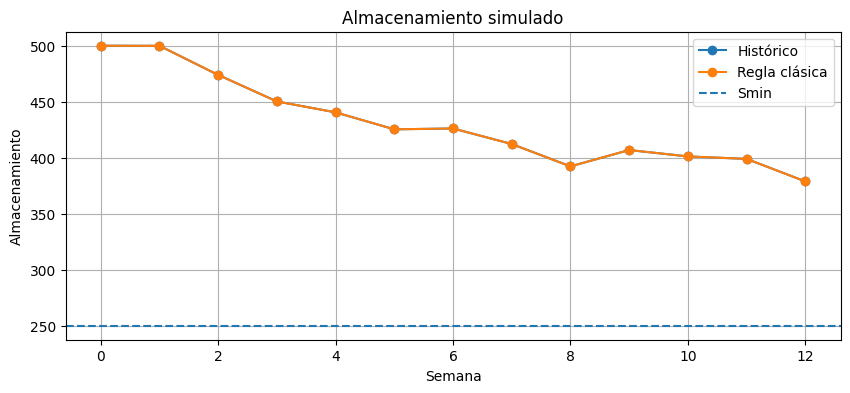

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(T + 1), S_hist, marker="o", label="Histórico")
plt.plot(range(T + 1), S_rule, marker="o", label="Regla clásica")
plt.axhline(params["Smin"], linestyle="--", label="Smin")
plt.title("Almacenamiento simulado")
plt.xlabel("Semana")
plt.ylabel("Almacenamiento")
plt.legend()
plt.grid(True)
plt.show()


## 13. Constructor QUBO/BQM

La siguiente clase crea una QUBO a partir de términos lineales y cuadrados de expresiones lineales.

Para cualquier expresión:

\[
\left(\alpha_0+\sum_i \alpha_i q_i\right)^2,
\]

con \(q_i\in\{0,1\}\), se usa \(q_i^2=q_i\), por lo que:

\[
\left(\alpha_0+\sum_i\alpha_iq_i\right)^2
=\alpha_0^2+
\sum_i(2\alpha_0\alpha_i+\alpha_i^2)q_i+
\sum_{i<j}2\alpha_i\alpha_jq_iq_j.
\]

Esto es exactamente una QUBO.


In [7]:
def x_name(t, k):
    sign = "p" if k >= 0 else "m"
    return f"x_t{t}_{sign}{abs(int(k))}"


def bit_name(prefix, t, p):
    if t is None:
        return f"{prefix}_b{p}"
    return f"{prefix}_t{t}_b{p}"


class QUBOBuilder:
    """
    Constructor simple de QUBO.
    Guarda Q como diccionario {(var_i, var_j): coeficiente}.
    """
    def __init__(self):
        self.Q = defaultdict(float)
        self.offset = 0.0

    def _key(self, a, b):
        return (a, b) if a <= b else (b, a)

    def add_linear(self, var, bias):
        if abs(bias) > 1e-12:
            self.Q[(var, var)] += float(bias)

    def add_quadratic(self, var1, var2, bias):
        if abs(bias) <= 1e-12:
            return
        if var1 == var2:
            self.add_linear(var1, bias)
        else:
            self.Q[self._key(var1, var2)] += float(bias)

    def add_square_linear(self, coeffs, constant=0.0, weight=1.0):
        """
        Agrega weight*(constant + sum_i coeffs[i]*q_i)^2.
        """
        coeffs = {v: float(c) for v, c in coeffs.items() if abs(c) > 1e-12}
        constant = float(constant)
        weight = float(weight)
        self.offset += weight * constant**2
        items = list(coeffs.items())
        for var, a in items:
            self.add_linear(var, weight * (2*constant*a + a*a))
        for i in range(len(items)):
            vi, ai = items[i]
            for j in range(i + 1, len(items)):
                vj, aj = items[j]
                self.add_quadratic(vi, vj, weight * 2*ai*aj)

    def clean(self, tol=1e-12):
        self.Q = defaultdict(float, {k: v for k, v in self.Q.items() if abs(v) > tol})
        return dict(self.Q), self.offset


## 14. Construcción de la QUBO Falcon

La función siguiente implementa:

\[
H(q)=H_{dev}+H_{smooth}+H_{crit}+H_{one}+H_R+H_S+H_B+H_{crit\_pen}.
\]

El modelo usa variables auxiliares binarias para aproximar holguras y déficit:

\[
d_t=\rho_S\sum_p2^p y^d_{t,p},
\]

\[
r_t=\rho_S\sum_p2^p y^r_{t,p},
\]

\[
g_t=\rho_S\sum_p2^p y^g_{t,p},
\]

\[
h_t=\rho_S\sum_p2^p y^h_{t,p}.
\]

La resolución \(\rho_S\) se controla con `aux_bits`. A más bits, mayor precisión y más variables binarias.


In [8]:
def binary_expansion(prefix, t, bits, resolution):
    """
    Devuelve diccionario {variable_binaria: coeficiente} para una expansión binaria.
    """
    return {bit_name(prefix, t, p): resolution * (2**p) for p in range(bits)}


def storage_expression(t, df, S0, delta_u, levels):
    """
    Regresa constant, coeffs para S_t = constant + sum coeffs[var]*x_var.
    """
    delta_s = df["delta_storage_obs"].to_numpy(dtype=float)
    constant = float(S0 + np.sum(delta_s[:t]))
    coeffs = {}
    for tau in range(t):
        for k in levels:
            coeffs[x_name(tau, k)] = coeffs.get(x_name(tau, k), 0.0) - delta_u * int(k)
    return constant, coeffs


def build_falcon_qubo(
    df,
    S0,
    Smax,
    params,
    aux_bits=5,
    balance_bits=6,
    P_one=25.0,
    P_crit=50.0,
    P_storage=50.0,
    P_balance=50.0,
    P_release=50.0,
):
    """
    Construye una QUBO para el problema Falcon con codificación one-hot de u_t.

    Pesos P_*: penalizaciones. Deben ser suficientemente grandes para favorecer factibilidad.
    En la práctica se calibran por sensibilidad.
    """
    T = len(df)
    levels = params["levels"]
    delta_u = params["delta_u"]
    release_obs = df["release_obs"].to_numpy(dtype=float)

    b = QUBOBuilder()

    # Resolución de holguras relacionadas con almacenamiento.
    # La expansión cubre aproximadamente [0, Smax].
    storage_resolution = Smax / (2**aux_bits - 1)

    # Resolución de holguras de balance.
    B = params["eta"] * np.sum(release_obs)
    balance_max = B + T * params["umax"]
    balance_resolution = max(balance_max / (2**balance_bits - 1), 1e-9)

    # 1) Selección única: una decisión de nivel por semana.
    for t in range(T):
        coeffs = {x_name(t, k): 1.0 for k in levels}
        b.add_square_linear(coeffs, constant=-1.0, weight=P_one)

    # 2) Cdev = sum u_t^2.
    for t in range(T):
        coeffs = {x_name(t, k): delta_u * int(k) for k in levels}
        b.add_square_linear(coeffs, constant=0.0, weight=params["w2"])

    # 3) Csmooth = sum (u_t - u_{t-1})^2.
    for t in range(1, T):
        coeffs = {}
        for k in levels:
            coeffs[x_name(t, k)] = coeffs.get(x_name(t, k), 0.0) + delta_u * int(k)
            coeffs[x_name(t-1, k)] = coeffs.get(x_name(t-1, k), 0.0) - delta_u * int(k)
        b.add_square_linear(coeffs, constant=0.0, weight=params["w3"])

    # 4) Ccrit con d_t^2 y penalización d_t - r_t = Smin - S_t.
    for t in range(T + 1):
        d_coeffs = binary_expansion("d", t, aux_bits, storage_resolution)
        r_coeffs = binary_expansion("r", t, aux_bits, storage_resolution)

        # costo w1*d_t^2
        b.add_square_linear(d_coeffs, constant=0.0, weight=params["w1"])

        # restricción d_t - r_t - Smin + S_t = 0
        S_const, S_coeffs = storage_expression(t, df, S0, delta_u, levels)
        coeffs = {}
        for var, c in d_coeffs.items():
            coeffs[var] = coeffs.get(var, 0.0) + c
        for var, c in r_coeffs.items():
            coeffs[var] = coeffs.get(var, 0.0) - c
        for var, c in S_coeffs.items():
            coeffs[var] = coeffs.get(var, 0.0) + c
        constant = S_const - params["Smin"]
        b.add_square_linear(coeffs, constant=constant, weight=P_crit)

    # 5) Restricción R(t) >= 0.
    # Como los niveles son discretos, penalizamos directamente niveles inválidos.
    for t in range(T):
        for k in levels:
            if release_obs[t] + delta_u * int(k) < -1e-9:
                b.add_linear(x_name(t, k), P_release)

    # 6) Restricciones de almacenamiento: S_t >= 0 y S_t <= Smax mediante holguras.
    for t in range(T + 1):
        S_const, S_coeffs = storage_expression(t, df, S0, delta_u, levels)
        g_coeffs = binary_expansion("g", t, aux_bits, storage_resolution)
        h_coeffs = binary_expansion("h", t, aux_bits, storage_resolution)

        # S_t - g_t = 0
        coeffs_low = dict(S_coeffs)
        for var, c in g_coeffs.items():
            coeffs_low[var] = coeffs_low.get(var, 0.0) - c
        b.add_square_linear(coeffs_low, constant=S_const, weight=P_storage)

        # Smax - S_t - h_t = 0
        coeffs_up = {var: -c for var, c in S_coeffs.items()}
        for var, c in h_coeffs.items():
            coeffs_up[var] = coeffs_up.get(var, 0.0) - c
        b.add_square_linear(coeffs_up, constant=Smax - S_const, weight=P_storage)

    # 7) Balance acumulado |sum u_t| <= eta*sum R_obs(t).
    # B - U - bplus = 0 y B + U - bminus = 0.
    U_coeffs = {}
    for t in range(T):
        for k in levels:
            U_coeffs[x_name(t, k)] = U_coeffs.get(x_name(t, k), 0.0) + delta_u * int(k)

    bplus = binary_expansion("bplus", None, balance_bits, balance_resolution)
    bminus = binary_expansion("bminus", None, balance_bits, balance_resolution)

    coeffs_pos = {var: -c for var, c in U_coeffs.items()}
    for var, c in bplus.items():
        coeffs_pos[var] = coeffs_pos.get(var, 0.0) - c
    b.add_square_linear(coeffs_pos, constant=B, weight=P_balance)

    coeffs_neg = dict(U_coeffs)
    for var, c in bminus.items():
        coeffs_neg[var] = coeffs_neg.get(var, 0.0) - c
    b.add_square_linear(coeffs_neg, constant=B, weight=P_balance)

    Q, offset = b.clean()
    variables = sorted({v for pair in Q for v in pair})
    metadata = {
        "T": T,
        "num_variables": len(variables),
        "num_terms": len(Q),
        "offset": offset,
        "storage_resolution": storage_resolution,
        "balance_resolution": balance_resolution,
        "variables": variables,
    }
    return Q, offset, metadata

Q, offset, qubo_meta = build_falcon_qubo(df, S0, Smax, params, aux_bits=4, balance_bits=5)
qubo_meta


{'T': 12,
 'num_variables': 278,
 'num_terms': 7466,
 'offset': 355522272.9552049,
 'storage_resolution': 66.66666666666667,
 'balance_resolution': np.float64(8.335621715517368),
 'variables': ['bminus_b0',
  'bminus_b1',
  'bminus_b2',
  'bminus_b3',
  'bminus_b4',
  'bplus_b0',
  'bplus_b1',
  'bplus_b2',
  'bplus_b3',
  'bplus_b4',
  'd_t0_b0',
  'd_t0_b1',
  'd_t0_b2',
  'd_t0_b3',
  'd_t10_b0',
  'd_t10_b1',
  'd_t10_b2',
  'd_t10_b3',
  'd_t11_b0',
  'd_t11_b1',
  'd_t11_b2',
  'd_t11_b3',
  'd_t12_b0',
  'd_t12_b1',
  'd_t12_b2',
  'd_t12_b3',
  'd_t1_b0',
  'd_t1_b1',
  'd_t1_b2',
  'd_t1_b3',
  'd_t2_b0',
  'd_t2_b1',
  'd_t2_b2',
  'd_t2_b3',
  'd_t3_b0',
  'd_t3_b1',
  'd_t3_b2',
  'd_t3_b3',
  'd_t4_b0',
  'd_t4_b1',
  'd_t4_b2',
  'd_t4_b3',
  'd_t5_b0',
  'd_t5_b1',
  'd_t5_b2',
  'd_t5_b3',
  'd_t6_b0',
  'd_t6_b1',
  'd_t6_b2',
  'd_t6_b3',
  'd_t7_b0',
  'd_t7_b1',
  'd_t7_b2',
  'd_t7_b3',
  'd_t8_b0',
  'd_t8_b1',
  'd_t8_b2',
  'd_t8_b3',
  'd_t9_b0',
  'd_t9_b1',
 

## 15. Resolución con recocido simulado

La resolución con recocido simulado permite validar el modelo BQM en instancias pequeñas. Para instancias oficiales o grandes, el reto sugiere QAOA, quantum annealing o enfoques híbridos.

> Recomendación práctica: comienza con \(T=12\), \(L=3\) o \(L=5\), y pocas variables auxiliares. Después escala a \(T=26\) y \(T=52\).


In [9]:
def decode_u_from_sample(sample, T, levels, delta_u):
    """
    Decodifica la solución binaria one-hot. Si el sampler no entrega una semana perfectamente one-hot,
    se elige el nivel con mayor valor binario y se reporta la suma one-hot para diagnóstico.
    """
    chosen_k = []
    onehot_sum = []
    for t in range(T):
        vals = {int(k): int(round(sample.get(x_name(t, k), 0))) for k in levels}
        onehot_sum.append(sum(vals.values()))
        chosen = max(vals, key=vals.get)
        chosen_k.append(chosen)
    u = delta_u * np.array(chosen_k, dtype=float)
    return u, chosen_k, onehot_sum


def solve_qubo_simulated_annealing(Q, offset, num_reads=200, seed=42):
    import dimod
    import neal
    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=offset)
    sampler = neal.SimulatedAnnealingSampler()
    sampleset = sampler.sample(bqm, num_reads=num_reads, seed=seed)
    return sampleset.first, sampleset

start = time.time()
best, sampleset = solve_qubo_simulated_annealing(Q, offset, num_reads=200, seed=42)
runtime = time.time() - start

u_qubo, chosen_k, onehot_sum = decode_u_from_sample(
    best.sample, T, params["levels"], params["delta_u"]
)
S_qubo = compute_storage(S0, df["delta_storage_obs"].to_numpy(dtype=float), u_qubo)
metrics_qubo = evaluate_srs(S_qubo, u_qubo, params["Smin"], params["w1"], params["w2"], params["w3"])
feas_qubo = constraint_report(df, S_qubo, u_qubo, params)

print("Energía BQM:", best.energy)
print("Tiempo de solución (s):", runtime)
print("Niveles k elegidos:", chosen_k)
print("Suma one-hot por semana:", onehot_sum)
print("Métricas:", metrics_qubo)
print("Factibilidad:", feas_qubo)


Energía BQM: 425393.2461477518
Tiempo de solución (s): 0.8783307075500488
Niveles k elegidos: [-2, -2, 1, 0, -1, -1, 1, -1, -2, -2, 2, -1]
Suma one-hot por semana: [1, 2, 2, 1, 1, 2, 2, 1, 3, 2, 1, 1]
Métricas: {'Ccrit': 0.0, 'Cdev': 2100.036845880061, 'Csmooth': 3634.6791563308743, 'penalty': 0.07973484848484849, 'SRS': -0.07973484848484849}
Factibilidad: {'min_R': 8.167981322506183, 'max_abs_u': 17.974498370576452, 'min_S': 437.2070271331441, 'max_S': 517.8780456293689, 'balance_lhs': 71.89799348230581, 'balance_rhs': 42.71029273412097, 'R_nonnegative': True, 'u_within_umax': True, 'S_within_bounds': True, 'balance_ok': False}


In [10]:
# Comparación de modelos
summary = []
for name, u, S in [
    ("Histórico", u_hist, S_hist),
    ("Regla clásica", u_rule, S_rule),
    ("QUBO / recocido simulado", u_qubo, S_qubo),
]:
    metrics = evaluate_srs(S, u, params["Smin"], params["w1"], params["w2"], params["w3"])
    feas = constraint_report(df, S, u, params)
    summary.append({"modelo": name, **metrics, **feas})

summary_df = pd.DataFrame(summary)
summary_df


,modelo,Ccrit,Cdev,Csmooth,penalty,SRS,min_R,max_abs_u,min_S,max_S,balance_lhs,balance_rhs,R_nonnegative,u_within_umax,S_within_bounds,balance_ok
0,Histórico,0.0,0.000000,0.000000,0.000000,-0.000000,26.142480,0.000000,378.862611,500.000000,0.000000,42.710293,True,True,True,True
1,Regla clásica,0.0,0.000000,0.000000,0.000000,-0.000000,26.142480,0.000000,378.862611,500.000000,0.000000,42.710293,True,True,True,True
2,QUBO / recocido simulado,0.0,2100.036846,3634.679156,0.079735,-0.079735,8.167981,17.974498,437.207027,517.878046,71.897993,42.710293,True,True,True,False


In [11]:
# Tabla semanal de resultados
result_df = df.copy()
result_df["u_qubo"] = u_qubo
result_df["R_qubo"] = result_df["release_obs"] + result_df["u_qubo"]
result_df["k_qubo"] = chosen_k
result_df["S_qubo_start"] = S_qubo[:-1]
result_df["S_qubo_end"] = S_qubo[1:]
result_df


,week,release_obs,delta_storage_obs,u_qubo,R_qubo,k_qubo,S_qubo_start,S_qubo_end
0,0,35.993428,-0.096453,-17.974498,18.018930,-2,500.000000,517.878046
1,1,39.048598,-25.959363,-17.974498,21.074100,-2,517.878046,509.893181
2,2,43.572433,-23.699014,8.987249,52.559682,1,509.893181,477.206918
3,3,45.964631,-9.747450,0.000000,45.964631,0,477.206918,467.459468
4,4,40.577690,-15.153973,-8.987249,31.590441,-1,467.459468,461.292743
5,5,36.785587,0.770968,-8.987249,27.798337,-1,461.292743,471.050960
6,6,35.904565,-13.896289,8.987249,44.891814,1,471.050960,448.167422
7,7,30.488873,-19.947644,-8.987249,21.501624,-1,448.167422,437.207027
8,8,26.142480,14.587785,-17.974498,8.167981,-2,437.207027,469.769311
9,9,28.808064,-5.709316,-17.974498,10.833566,-2,469.769311,482.034493


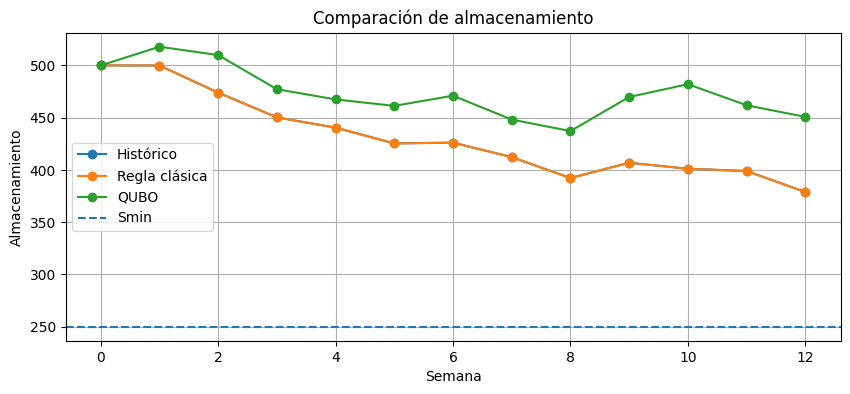

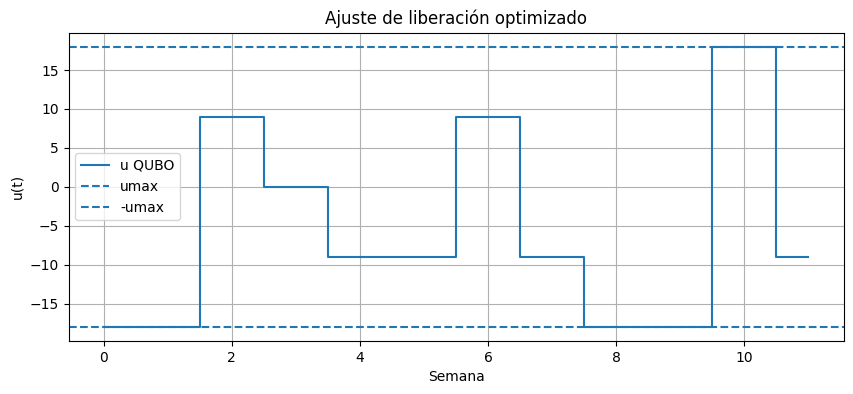

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(range(T + 1), S_hist, marker="o", label="Histórico")
plt.plot(range(T + 1), S_rule, marker="o", label="Regla clásica")
plt.plot(range(T + 1), S_qubo, marker="o", label="QUBO")
plt.axhline(params["Smin"], linestyle="--", label="Smin")
plt.title("Comparación de almacenamiento")
plt.xlabel("Semana")
plt.ylabel("Almacenamiento")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.step(range(T), u_qubo, where="mid", label="u QUBO")
plt.axhline(params["umax"], linestyle="--", label="umax")
plt.axhline(-params["umax"], linestyle="--", label="-umax")
plt.title("Ajuste de liberación optimizado")
plt.xlabel("Semana")
plt.ylabel("u(t)")
plt.legend()
plt.grid(True)
plt.show()


## 16. Exportación de resultados

La entrega del reto debe reportar al menos:

- secuencia optimizada \(u^{opt}(t)\);
- liberación optimizada \(R^{opt}(t)=R^{obs}(t)+u^{opt}(t)\);
- almacenamiento optimizado \(S^{opt}(t)\);
- \(SRS_{opt}\), \(SRS_{baseline}\) y \(\Delta SRS\);
- tiempo de ejecución;
- comportamiento de escalamiento con \(T\) y \(L\).


In [ ]:
# Exporta resultados para descarga.
result_df.to_csv("falcon_qubo_resultados.csv", index=False)
summary_df.to_csv("falcon_qubo_resumen.csv", index=False)

try:
    from google.colab import files
    files.download("falcon_qubo_resultados.csv")
    files.download("falcon_qubo_resumen.csv")
except Exception:
    print("Archivos guardados en el directorio de trabajo: falcon_qubo_resultados.csv y falcon_qubo_resumen.csv")


## 17. Escalamiento recomendado

El reto propone tres niveles:

| Instancia | Semanas \(T\) | Niveles \(L\) | Uso |
|---|---:|---:|---|
| Pequeña | 12 | 3 | validación y depuración |
| Mediana | 26 | 5 | benchmark oficial |
| Grande | 52 | 5 o 7 | análisis de escalamiento |

El número de calendarios candidatos crece como:

\[
N_{schedules}=L^T.
\]

Con one-hot, las variables principales son:

\[
N_x=T\cdot L.
\]

Por ejemplo, para el benchmark mediano:

\[
N_x=26\cdot 5=130,
\]

sin contar variables auxiliares.


## 18. Interpretación de la solución QUBO

Una solución binaria entrega una selección por semana:

\[
x_{t,k}=1.
\]

De ahí se recupera:

\[
u_t=k\Delta u.
\]

Luego se calcula:

\[
R_t=R^{obs}_t+u_t,
\]

\[
S_{t+1}=S_t+\Delta S^{obs}_t-u_t.
\]

Finalmente se evalúa:

\[
SRS=-\left(w_1C_{crit}+w_2C_{dev}+w_3C_{smooth}\right).
\]

Una solución útil no sólo debe tener buen SRS; también debe cumplir restricciones. Si una solución de annealing viola one-hot, almacenamiento o balance, se deben aumentar penalizaciones, mejorar la discretización auxiliar o usar un solucionador híbrido.


## 19. Limitaciones del modelo

Este cuaderno documenta una formulación QUBO reproducible para el benchmark simplificado. No pretende producir una política operativa oficial del Falcon Reservoir.

Puntos que deben revisarse en una entrega final:

1. usar unidades consistentes entre almacenamiento, liberación y cambio de almacenamiento;
2. calibrar penalizaciones \(P_{one},P_{crit},P_S,P_B,P_R\);
3. validar que las variables auxiliares cubran los rangos necesarios;
4. comparar contra la línea histórica y la regla clásica;
5. reportar sensibilidad de \(T\), \(L\), pesos y resolución auxiliar;
6. separar claramente resultados oficiales de análisis de sensibilidad.


## 20. Conclusión

La formulación QUBO del problema Falcon queda como:

\[
\boxed{\min_{q\in\{0,1\}^N}q^TQq}
\]

con variables principales:

\[
x_{t,k}\in\{0,1\},\qquad k\in\{-2,-1,0,1,2\}.
\]

La función objetivo incorpora la penalización oficial del SRS y las restricciones operativas mediante términos cuadráticos. Esta estructura es compatible con BQM, recocido simulado, quantum annealing y solucionadores híbridos.
